# I. Baseline: Loistic Regression

Load Fashion-MNIST and train a simple loistic regression model.

### 1. Environment Setup

In [ ]:
# conda install pytorch torchvision torchaudio cpuonly -c pytorch # pip -q install torch torchvision torchaudio  
# conda install numpy matplotlib scikit-learn

In [1]:
# test (safe import)
import sys
print(sys.executable)
import numpy
print("Numpy loaded successfully")

d:\miniconda3\envs\dl_env\python.exe
Numpy loaded successfully


In [2]:

import torch, torch.nn as nn, torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

### 2. Load data  visualize

`datasets.FashionMNIST` function is a built-in utility from the `torchvision` library designed to handle the "boring" parts of data science: downloading, formatting, and preparing images for a neural network.

0.2%

100.0%


Extracting ../data\FashionMNIST\raw\train-images-idx3-ubyte.gz to ../data\FashionMNIST\raw



100.0%


Extracting ../data\FashionMNIST\raw\train-labels-idx1-ubyte.gz to ../data\FashionMNIST\raw



100.0%


Extracting ../data\FashionMNIST\raw\t10k-images-idx3-ubyte.gz to ../data\FashionMNIST\raw



100.0%


Extracting ../data\FashionMNIST\raw\t10k-labels-idx1-ubyte.gz to ../data\FashionMNIST\raw



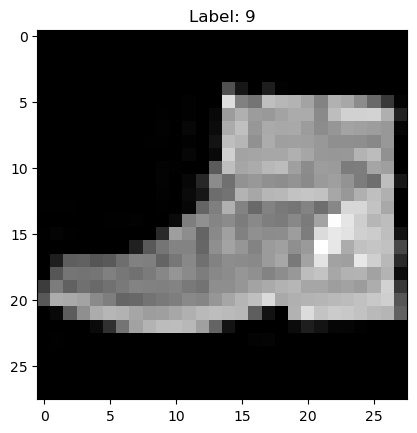

In [3]:
# 1. define the transformation to convert images to tensors
tfm = transforms.Compose([transforms.ToTensor()])
# 2. download and load the FashionMNIST dataset
train = datasets.FashionMNIST('../data', train=True, download=True, transform=tfm)
test = datasets.FashionMNIST('../data', train=False, download=True, transform=tfm)
# 3. create data loaders for training and testing datasets
train_dl = DataLoader(train, batch_size=256, shuffle=True)
test_dl = DataLoader(test, batch_size=256, shuffle=False)

# 4. visualize a sample image from the training dataset
images, labels = next(iter(train_dl))
plt.imshow(images[0].squeeze(), cmap='gray')
plt.title(f"Label: {labels[0].item()}")
plt.show()

### 3. Define baseline model (logistic regression)

In [ ]:
# Flatten 28*28 pixels = 784 inputs. 10 = number of clothing categories
model = nn.Linear(28*28, 10) 

# the Optimizer
opt = torch.optim.SGD(model.parameters(), lr=0.1)

### 4. Training Loop

In [ ]:
# Train 5 epochs
def train_epoch():
    model.train(); loss_sum=0
    # pass in the training data in batches from the data loader
    for x,y in train_dl:
        # flatten the images to 1D vectors
        x=x.view(x.size(0), -1)
        # forward pass: get the model's current guess
        out=model(x)
        # calculate loss: how far off was the guess
        loss=F.cross_entropy(out,y)
        # backward pass: calculate gradients (which weights cause the error)
        opt.zero_grad()
        loss.backward()
        # update the weights using the gradients
        opt.step()
        loss_sum+=loss.item()*x.size(0)
    return loss_sum/len(train)

for ep in range(5): print(f"epoch {ep+1}: loss={train_epoch():.4f}")

epoch 1: loss=0.7876
epoch 2: loss=0.5726
epoch 3: loss=0.5254
epoch 4: loss=0.5010
epoch 5: loss=0.4859


Improved in lower loss through each iteraction. But the gradient starts to slow down.

### 5. Evaluation & Confusion Matrix

In [ ]:
import numpy as np, sklearn.metrics as M
model.eval()
preds, targs = [], []

with torch.no_grad():
    for x,y in test_dl:
        p = model(x.view(x.size(0),-1)).argmax(1)
        preds += p.tolist(); targs += y.tolist()
print("Accuracy:", M.accuracy_score(targs, preds))
print(M.confusion_matrix(targs, preds))

Accuracy: 0.8225
[[773   6  27  53   5   1 119   0  16   0]
 [  4 938  14  34   6   0   2   0   2   0]
 [ 16   4 818   7  90   1  56   0   8   0]
 [ 24  13  25 851  31   1  52   0   3   0]
 [  0   2 226  35 654   0  78   0   5   0]
 [  1   0   0   2   0 873   0  71   4  49]
 [125   3 185  35  88   1 536   0  27   0]
 [  0   0   0   0   0  35   0 926   0  39]
 [  1   1  21   9   2   6  22   8 930   0]
 [  0   0   0   0   0  15   1  57   1 926]]


- The Diagonal (Top-left to Bottom-right): These are the correct predictions. For example, the first number 773 means the model correctly identified 773 T-shirts.
- The Off-Diagonal numbers: These are the mistakes:
    - The biggest confusion: 
        - Row 4: 226
        - Row 6: 125, 185

### 6. Error Analysis: Inspect to mistakes

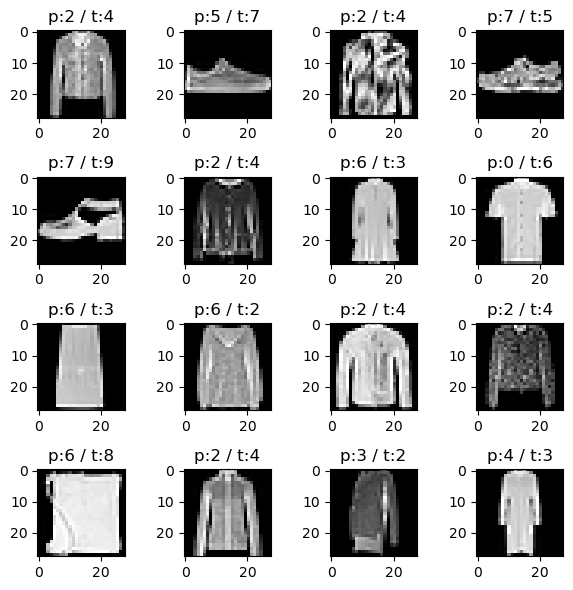

In [7]:
import itertools
wrong = [i for i,(p,t) in enumerate(zip(preds,targs)) if p!=t][:16]
grid = plt.figure(figsize=(6,6))
for j,i in enumerate(wrong):
    ax = grid.add_subplot(4,4,j+1); img,_ = test[i]
    ax.imshow(img.squeeze(), cmap='gray')
    ax.set_title(f"p:{preds[i]} / t:{targs[i]}")
plt.tight_layout()

- `p` as predicted, `t` as target/actual
    - `p2, t4`: the model mistakes 2 (pullover) for 4 (coat)
    - `p7, t9`: the model mistakes 7 (sneaker) fo 9 (ankle boot)

#### Conclusion:
One single layer (Logistic Regression) here cannot learn complex relationships.

---
# II. Perceptron (NumPy) MLP
- The Logic:
As a Neural Network is Matric Multiplication and Calculus, build the gradients with NumPy Perceptron to see how the weights are upradted with the added hidden layers to reduce errors.

- Actions:
    - Explore activation functions.
    - Implement NumPy Perceptron on a toy dataset.
    - Adding a "processing center" (Hidden Layer) that combines those spots into shapes like lines or curves.
    - 2-layer MLP (Multi-Layer Perceptron) and backprop to solve XOR (Exclusive OR).

### 1. Perceptron on linearly separable data

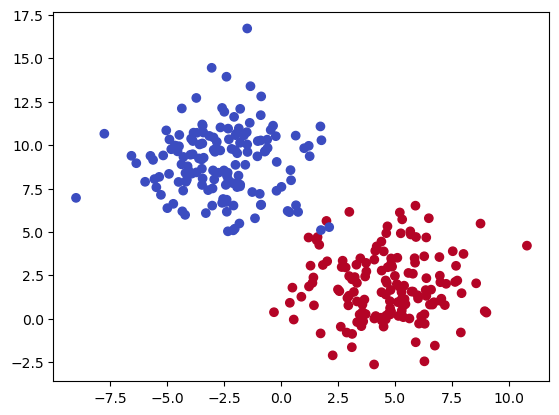

In [8]:
from sklearn.datasets import make_blobs
X,y = make_blobs(n_samples=300, centers=2, random_state=42, cluster_std=2)
X = np.c_[np.ones((X.shape[0],1)), X] # bias term
w = np.zeros(X.shape[1]); lr=0.1
for epoch in range(20):
    for i in range(len(X)):
        pred = 1 if X[i]@w >= 0 else 0
        w += lr*(y[i]-pred)*X[i]
# plot boundary
x1 = np.linspace(X[:,1].min(), X[:,1].max(), 100)
x2 = -(w[0]+w[1]*x1)/w[2]; plt.scatter(X[:,1],X[:,2],c=y,cmap='coolwarm')

### 2. Activation functions & derivatives

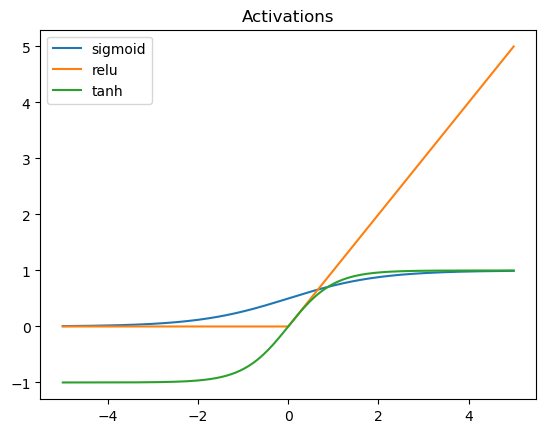

In [9]:
a = np.linspace(-5,5,400)
def sigmoid(z): return 1/(1+np.exp(-z))
def dsigmoid(z): s=sigmoid(z); return s*(s-1)*-1
def relu(z): return np.maximum(0,z)
def drelu(z): return (z>0).astype(float)
def tanh(z): return np.tanh(z)
def dtanh(z): return 1-np.tanh(z)**2
for f,name in [(sigmoid,'sigmoid'),(relu,'relu'),(tanh,'tanh')]:
    plt.plot(a, f(a), label=name)
plt.legend(); plt.title('Activations'); plt.show()

### 3. Manual backprop on XOR (2-2-1 MLP)

In [10]:
np.random.seed(0)
X = np.array([[0,0],[0,1],[1,0],[1,1]], dtype=float) # XOR
y = np.array([[0],[1],[1],[0]], dtype=float)
def init():
    W1=np.random.randn(2,2)*0.5; b1=np.zeros((1,2))
    W2=np.random.randn(2,1)*0.5; b2=np.zeros((1,1))
    return W1,b1,W2,b2
W1,b1,W2,b2 = init(); lr=0.1
def forward(X):
    z1=X@W1+b1; a1=np.tanh(z1)
    z2=a1@W2+b2; a2=1/(1+np.exp(-z2)) # sigmoid
    return z1,a1,z2,a2
for epoch in range(5000):
    z1,a1,z2,a2 = forward(X)
    loss = ((a2-y)**2).mean()
    # backprop
    da2 = 2*(a2-y)/len(X); dz2 = da2*(a2*(1-a2))
    dW2 = a1.T@dz2; db2 = dz2.sum(0, keepdims=True)
    da1 = dz2@W2.T; dz1 = da1*(1-np.tanh(z1)**2)
    dW1 = X.T@dz1; db1 = dz1.sum(0, keepdims=True)
    # update
    W1-=lr*dW1; b1-=lr*db1; W2-=lr*dW2; b2-=lr*db2
    if epoch%500==0: print(epoch, "loss=", round(float(loss),4))
print("Predictions:", (forward(X)[3]>0.5).astype(int).ravel())


0 loss= 0.2455
500 loss= 0.1753
1000 loss= 0.1468
1500 loss= 0.1372
2000 loss= 0.1331
2500 loss= 0.1309
3000 loss= 0.1296
3500 loss= 0.1288
4000 loss= 0.1282
4500 loss= 0.1277
Predictions: [0 0 1 1]


### 4. Activation comparison
Re‑run the XOR MLP with ReLU vs tanh (change acvaon + derivave) and compare final loss & convergence speed.

The Result: The model can now create "curved" decision boundaries. It can finally say: "If it has a long shape AND a gap in the middle (zipper), it's a Coat; otherwise, it's a Pullover."

# III. Optimization (the efficiency upgrade)
Fine-tuning the speed and efficiency of that brain so it learns faster and deeper. (Accuracy ~90%+)
Once you have a deeper brain (MLP), it becomes harder to train. The "mountain" of loss becomes more rugged and full of traps.

The Focus: Lab 1.3 teaches you Optimizers (like Momentum and Adam) and Loss Functions (Cross-Entropy vs. MSE).

The Interpretation: If SGD is "walking down a hill," Momentum is like "rolling a ball down a hill"—it gains speed and doesn't get stuck in small divots. This prevents the "Kernel Crash" or "Vanishing Gradient" issues that happen as models get bigger.


Compare Loss Functions and Optimizers with Basic Learning Rate Scheduling

Loss Functions: MSE vs Cross-Entropy.

Optimizers: SGD, Momentum, Adam
